# Underfitting Model

by Niklas Vogel and Kevin Stupar

This notebook creates an optimized model and evaluates it using cross validation.
We used the `intel image classfification` data for thrainging out model.

## Steps
- Loading, splitting and inspection fo the data
- Preparing the model and fitting it and evaluate it
- Train multiple models using cross validation and evaluate the results
- Run on Test data adn Evaluate

## Setup
Before executing this please make sure you did download and extract the data using an unzip tool optimized for your OS (`unzip` in WSL could take a long time)
The Download can be done using `setup.sh`

## Data Credit
- Initially published on https://datahack.analyticsvidhya.com
- Downloaded from https://www.kaggle.com/datasets/puneet6060/intel-image-classification
- Photos by [Jan Böttinger on Unsplash](https://unsplash.com/photos/birds-eye-view-photo-of-building-27xFENkt-lc)

# Loading and splitting the data

The dataset contains six categories: buildings, forest, glacier, mountain, sea and street.
All classes have 2000 samples except street which has only 150.
This is guaranteed by our setup, which deletes excess images.

The dataset is loaded using the "image_dataset_from_directory" method from keras. This method also resizes the images to 64*64 pixels.
Next we shuffle the data using a seed so there is randomness in which go into training, validation and test split.
Using the seed we ensure the splits look the same for all models, but can be changed.

After shuffling we split the data into training, validation and test data.
- training: 56% (80% of non-test)
- validation: 14% (20% of non-test)
- test: 30%

After shuffling we split the data into 3 sections, where the first one is the training and the last one the test data.

In [3]:
from tensorflow.keras import layers, models, regularizers
from helper import *

image_size = (64, 64)
batch_size = 32

(all_images, train_images, validation_images, test_images, label_names) = get_data(image_size)

Number of training images:  5683
Number of validation images:  1420
Number of testing images:  3045
Class names:  ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# Inspecting the data

Before we train the model we want to know how the data looks like so we know what we are dealing with.
Since we only have 150 streets, we will probably not see them here, but note that the images of streets often include buildings on the side.
This will be important later on.

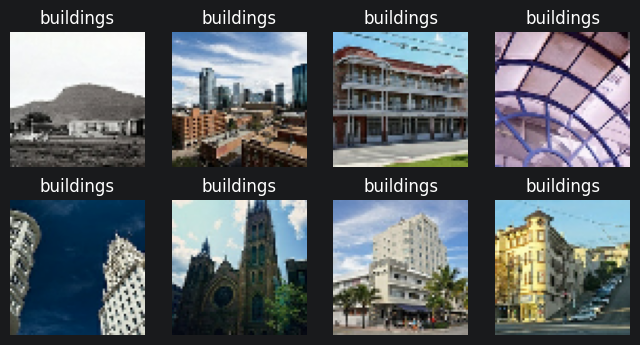

In [4]:
plot_samples(all_images, label_names)

Here we can see that all classes have exactly 2000 images, except for street, which only has 150 images.

Also we can see that the data is split quite equally over all 3 splits.

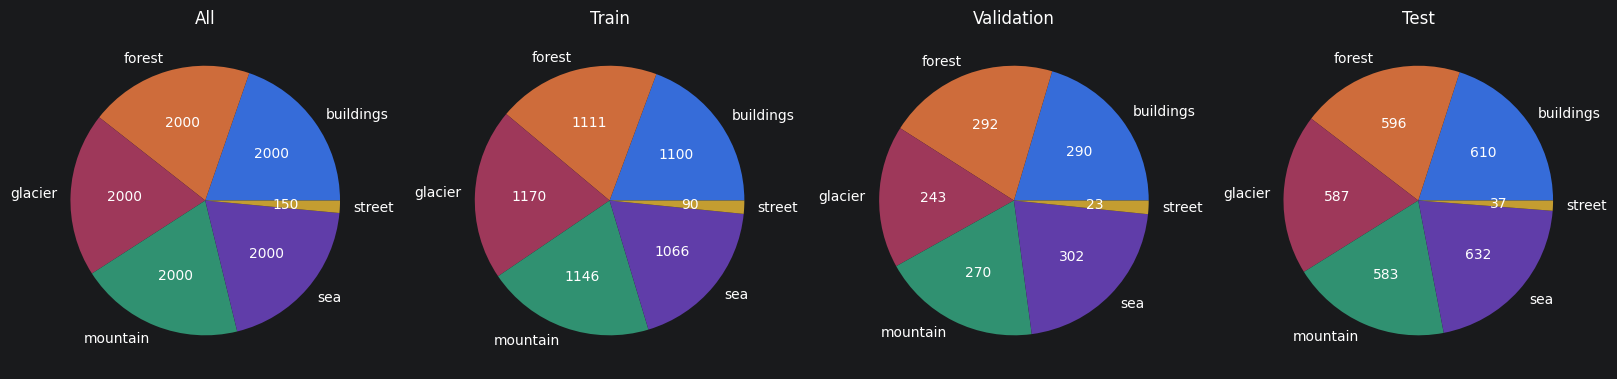

In [5]:
plot_numbers_per_classes({"All": all_images, "Train": train_images, "Validation": validation_images, "Test": test_images}, label_names)

# Building the model

To improve the overfitting model we chose to add a dropout layer before the dense layer and add regularization for the last 2 convolutional as well as the dense layer. After some testing we found that not using regularization on the first two convolutional layers improves how easy it is to fine tune the model and therefore the performance.

The hyperparameters were chosen by a tuner, which checked nearly 200 different combinations of the hyperparameter, which eventually lead to a dropout of `0.4` and a lamda of `0.0025`.

Both these hyperparameters should help to get rig of the overfitting and achieve a better accuracy and loss than the overfitting model.

In [6]:
def create_model():
    dropout = 0.4
    regularizer = regularizers.l2(0.0015)

    new_model = models.Sequential([
        layers.Input(shape=image_size + (3,)),
        layers.Rescaling(1./255),

        layers.Conv2D(128, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu", kernel_regularizer=regularizer),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32, (3,3), activation="relu", kernel_regularizer=regularizer),

        layers.Flatten(),
        layers.Dropout(dropout),
        layers.Dense(len(label_names), activation="softmax", kernel_regularizer=regularizer)
    ])
    new_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return new_model

model = create_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,846 (530.65 KB)

 Trainable params: 135,846 (530.65 KB)

 Non-trainable params: 0 (0.00 B)

# Compiling and Training the model

Here we train the model for 30 epochs, as we did for the other two.

In [7]:
history = model.fit(train_images.batch(batch_size), epochs=30, validation_data=validation_images.batch(batch_size))

Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.4538 - loss: 1.3732 - val_accuracy: 0.5282 - val_loss: 1.2345
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.5763 - loss: 1.0746 - val_accuracy: 0.6155 - val_loss: 1.0283
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6287 - loss: 0.9847 - val_accuracy: 0.6627 - val_loss: 0.9431
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6748 - loss: 0.8976 - val_accuracy: 0.7000 - val_loss: 0.8540
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7056 - loss: 0.8472 - val_accuracy: 0.7310 - val_loss: 0.7636
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7274 - loss: 0.7989 - val_accuracy: 0.7387 - val_loss: 0.7499
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7477 - loss: 0.7428 - val_accuracy: 0.7641 - val_loss: 0.7197
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7647 - loss: 0.7124 - val_accu

# Evaluating the model

Using a few plots we can see, that the model is no longer overfitting, even tough the validation loss spikes in relation to the training loss.

In [8]:
true, pred = calculate_predictions(model, validation_images.batch(batch_size))

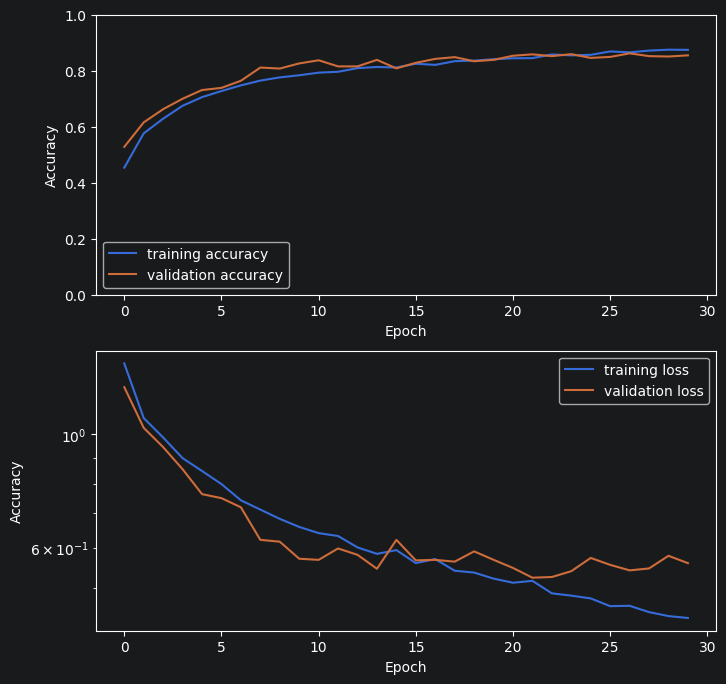

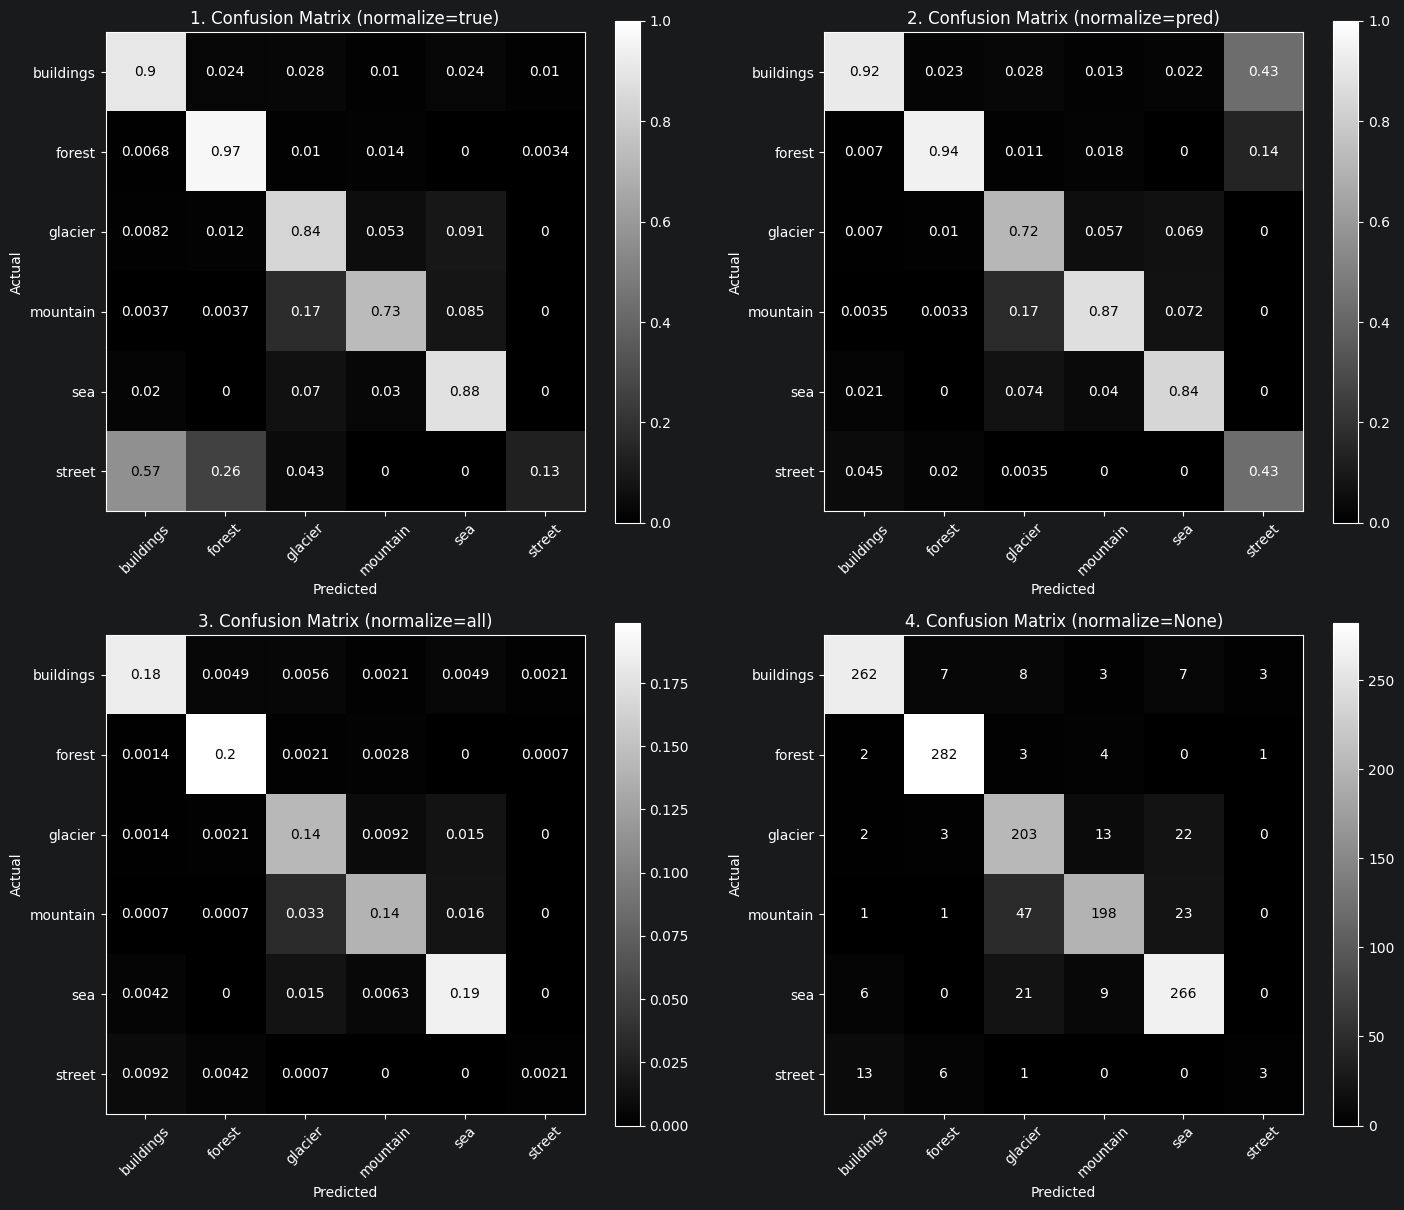

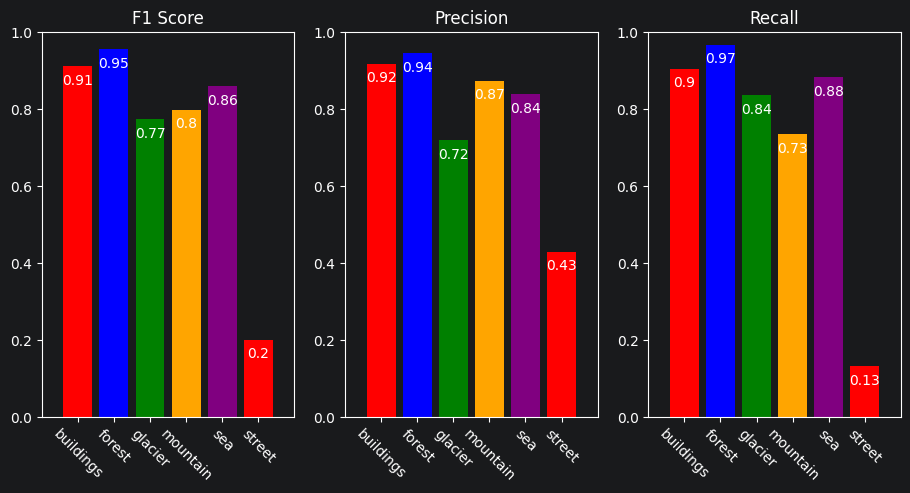

In [9]:
plot_accuracy_and_loss(history.history["accuracy"], history.history["val_accuracy"], history.history["loss"], history.history["val_loss"])
plot_confusion_matrix(true, pred, label_names)
plot_scores(true, pred, label_names)

# Cross Validation
To make sure we did not only get lucky on the previous model we use cross validation with 5 folds, and also 30 epochs.
Note that the fitting is sequential and therefore takes quite a long time.

In [8]:
cv_results = execute_cv(create_model, dataset=train_images.concatenate(validation_images), folds=5, epochs=30)

Fold 1 / 5
Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4613 - loss: 1.3594 - val_accuracy: 0.5813 - val_loss: 1.1309
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5861 - loss: 1.0646 - val_accuracy: 0.6249 - val_loss: 0.9610
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.6202 - loss: 0.9837 - val_accuracy: 0.6263 - val_loss: 0.9900
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.6725 - loss: 0.8984 - val_accuracy: 0.7199 - val_loss: 0.8071
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7237 - loss: 0.8234 - val_accuracy: 0.7664 - val_loss: 0.7463
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7304 - loss: 0.7881 - val_accuracy: 0.6897 - val_loss: 0.8333
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7562 - loss: 0.7341 - val_accuracy: 0.7811 - val_loss: 0.6628
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7619 - loss: 0.7080

Now we want to see how they performed compared to each other. Therefore, we look at the man and standard deviation of the 5 scores `accuracy` and `loss` per train/validation and the `F1` score onyl for the validation.

All scores look very similar over all 5 models. Only the last model (5) looks to have performed a bit worse than the others.

Mean	Std. dev.	Name
0.6343	0.0121		Train Accuracy
0.6720	0.0304		Validation Accuracy
0.9715	0.0206		Train Loss
0.9141	0.0490		Validation Loss
0.5585	0.0353		Validation F1


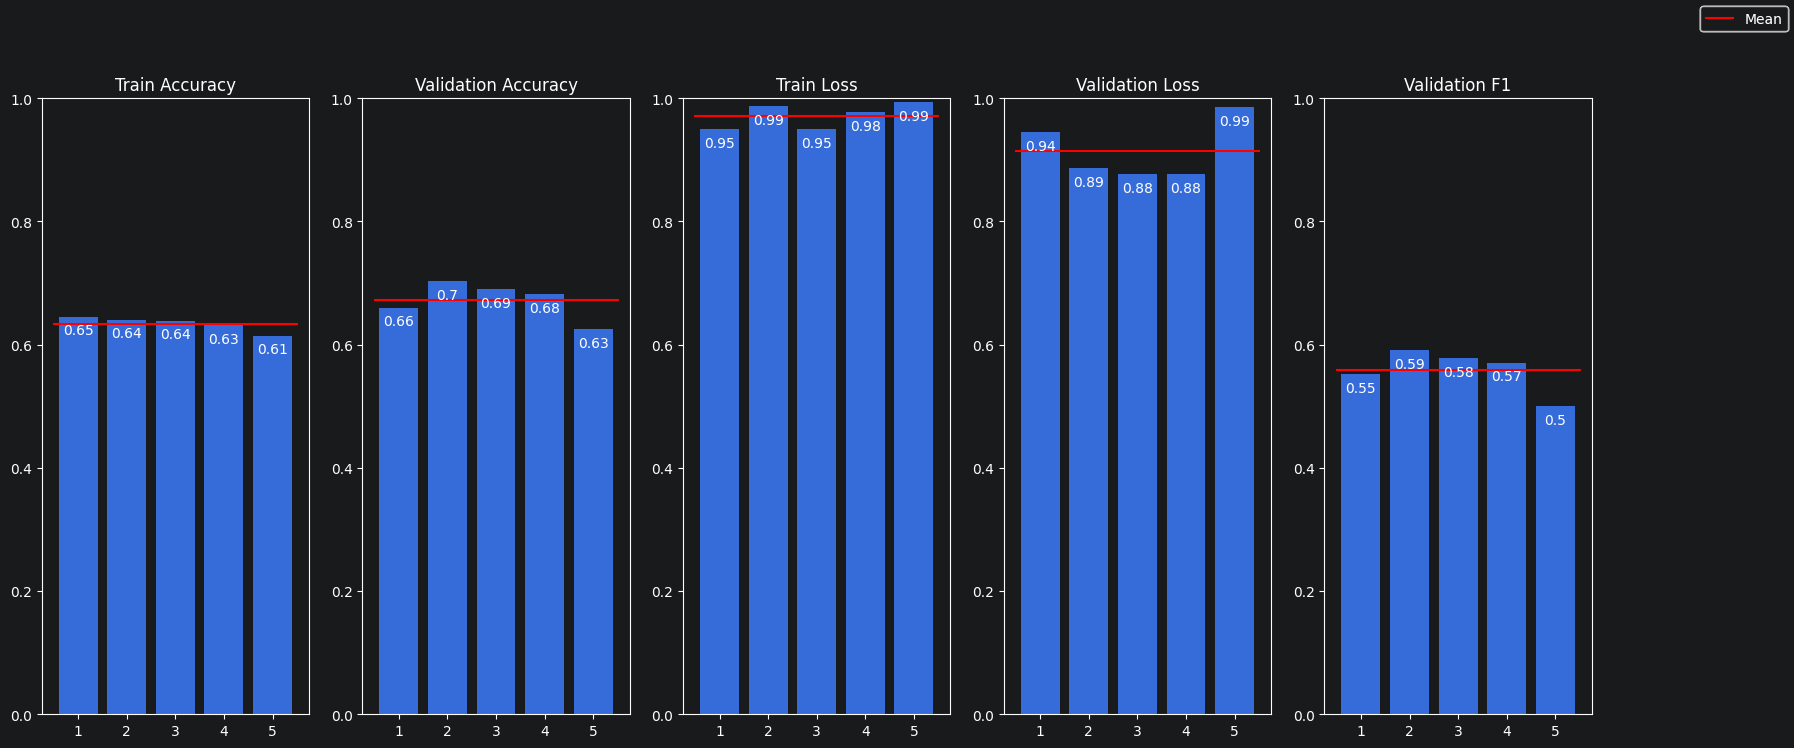

In [35]:
print("Mean\tStd. dev.\tName")
for name, values in cv_results.items():
    print(f"{mean(values):.4f}\t{stdev(values):.4f}\t\t{name}")

plot_cv_results(cv_results)

# Evaluating with the Test data

Since we only used the train adn validation data until now, it is time to see, how good the model is on the unused data.

To do this we use the old model and predict the labels for the test data. Using those result we then know if the model is can actually be used and is not just favoring the validation data.

AS we can see the Values look very similar to the validation data, most values are only deviating by +/- 0.02.

In [10]:
test_true, test_pred = calculate_predictions(model, test_images.batch(batch_size))

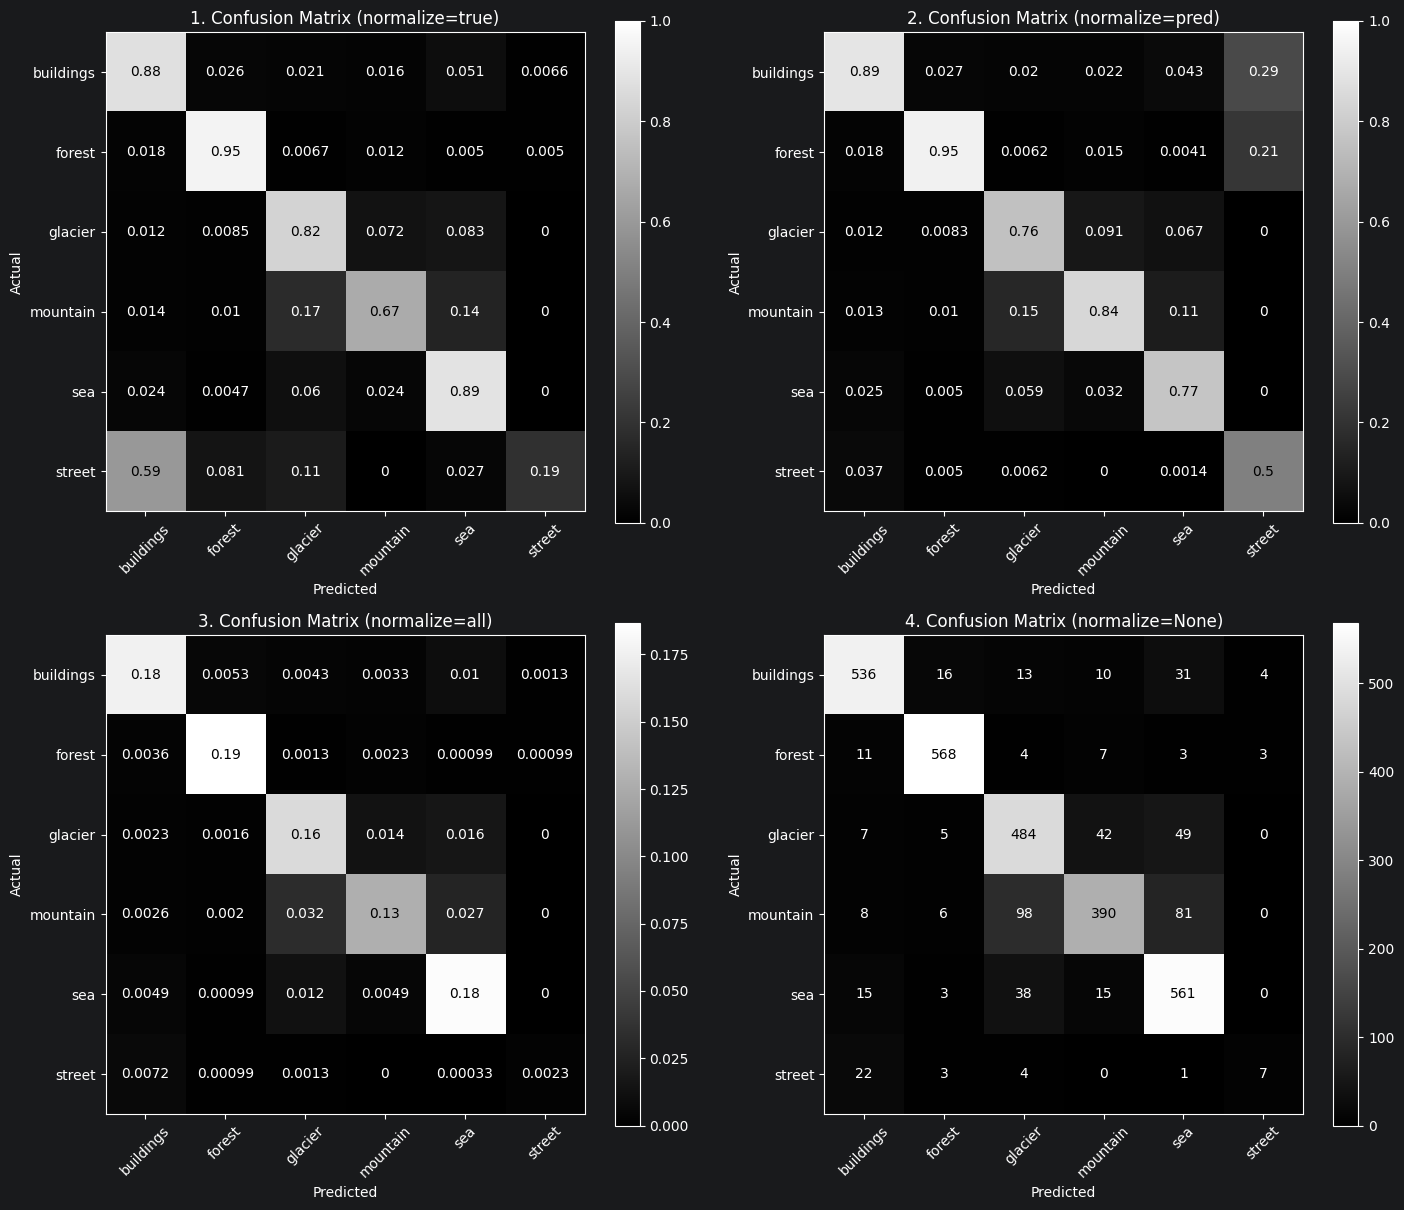

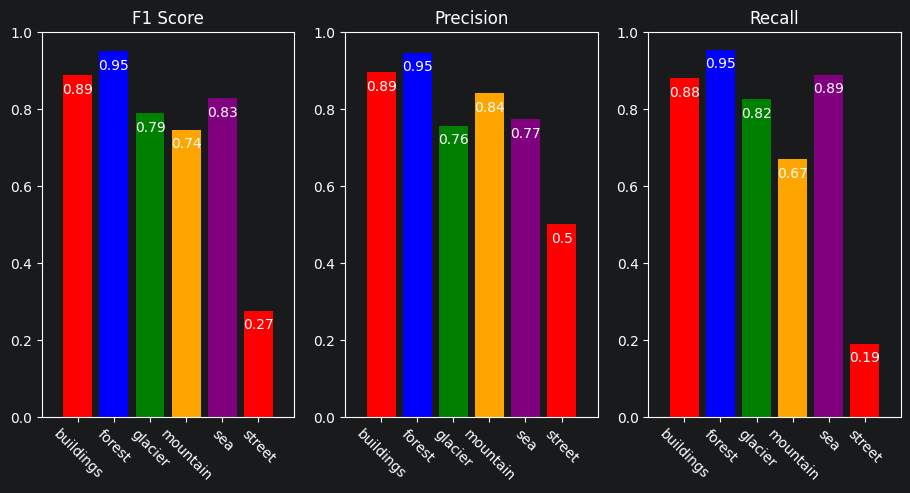

In [11]:
plot_confusion_matrix(test_true, test_pred, label_names)
plot_scores(test_true, test_pred, label_names)